<a href="https://colab.research.google.com/github/khanyisa-mabasa/KHANYISA-MABASA-PORTFOLIOO/blob/main/Fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import libraries
import pandas as pd  # For loading and handling data
from sklearn.model_selection import train_test_split  # To split data into train/test
from sklearn.preprocessing import StandardScaler  # To normalize numerical features
from sklearn.linear_model import LogisticRegression  # Our ML model (simple binary classifier)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # For evaluation
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns  # For nicer confusion matrix plot


In [ ]:
# Step 2: Load the dataset (replace 'creditcard.csv' with your file path if different)
df = pd.read_csv('creditcard.csv')
print("Dataset loaded. Shape:", df.shape)                    # Should be (284807, 31)
print("Class distribution:\n", df['Class'].value_counts())  # 0: normal, 1: fraud

Dataset loaded. Shape: (284807, 31)
Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
# Step 3: Preprocess data
# Normalize 'Time' and 'Amount' (V1-V28 are already PCA-transformed and scaled)
scaler = StandardScaler()
df['Time'] = scaler.fit_transform(df[['Time']])
df['Amount'] = scaler.fit_transform(df[['Amount']])

In [ ]:
# Handle imbalance: Downsample normal (Class=0) to match fraud count
normal = df[df['Class'] == 0].sample(n=df['Class'].value_counts()[1], random_state=42)  # Sample equal to frauds
fraud = df[df['Class'] == 1]
df_balanced = pd.concat([normal, fraud]).sample(frac=1, random_state=42)  # Shuffle

In [ ]:
# Features (X) and target (y)
X = df_balanced.drop('Class', axis=1)  # All columns except Class
y = df_balanced['Class']  # Target: 0 or 1

In [ ]:
# Step 4: Split data into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (787, 30) Test shape: (197, 30)


In [ ]:
# Step 5: Train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)  # Increase max_iter if convergence warning
model.fit(X_train, y_train)  # Fit on train data
print("Model trained!")

Model trained!


In [ ]:
# Step 6: Evaluate the model
y_pred = model.predict(X_test)  # Predict on test
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)                               # Expect ~0.92-0.95 for this data (slightly lower than Random Forest)

Accuracy: 0.9289340101522843


In [ ]:
# Detailed report: Precision (few false positives), Recall (catch most frauds), F1 (balance)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94       110
           1       0.97      0.86      0.91        87

    accuracy                           0.93       197
   macro avg       0.94      0.92      0.93       197
weighted avg       0.93      0.93      0.93       197



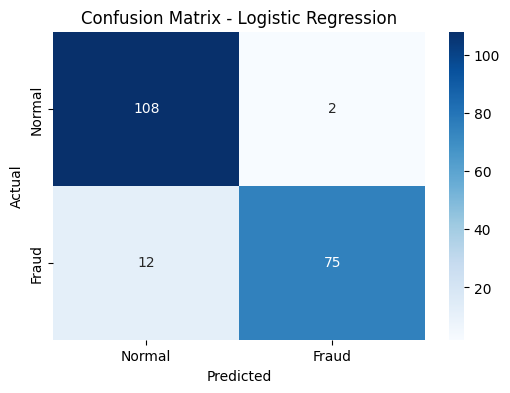

In [ ]:
# Confusion Matrix: Visualizes true positives (fraud caught), false negatives (missed fraud), etc.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

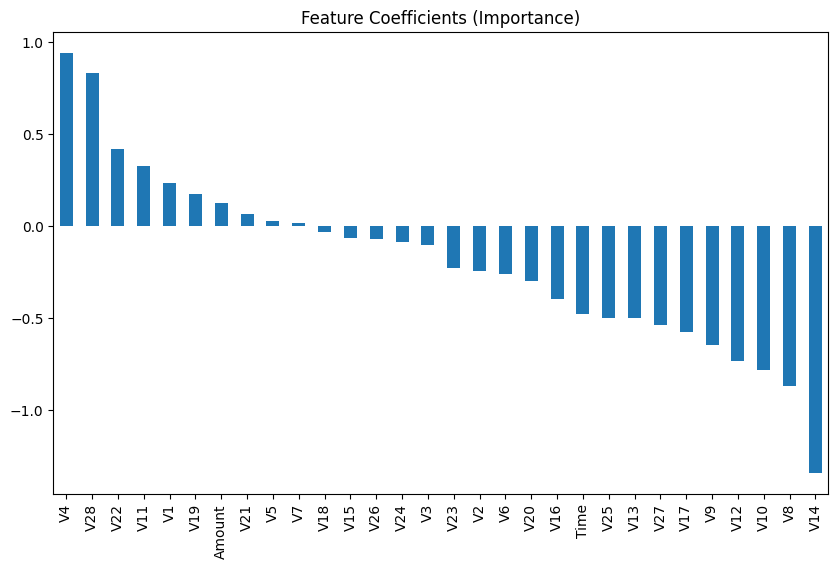

In [ ]:
# Coefficients: Feature importance (higher absolute value = more impact)
importances = pd.Series(model.coef_[0], index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,6))
plt.title('Feature Coefficients (Importance)')
plt.show()

In [ ]:
# Step 7: Predict on new data (example: take a row from test set or make one)
# New transaction: Use actual values; here, first test row as example
new_transaction = X_test.iloc[0].values.reshape(1, -1)  # Reshape for single prediction
prediction = model.predict(new_transaction)
prob = model.predict_proba(new_transaction)[0][1]  # Probability of fraud
print("\nNew Transaction Prediction:", "Fraud" if prediction[0] == 1 else "Normal")
print("Fraud Probability:", prob)


New Transaction Prediction: Normal
Fraud Probability: 0.0036880188847918656


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
